In [1]:
#multi layer perceptron on MNIST dataset and predicting the digit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from keras import layers
import warnings
warnings.filterwarnings("ignore")


In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()
print(x_train.shape)
print(x_test.shape)
x_train = x_train/255.0
x_test = x_test/255.0
#flatten images
x_train  = x_train.reshape(-1,784)
x_test  = x_test.reshape(-1,784)
print(x_train.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 784)


In [3]:
#buildidng mlp model ---> sequential model
model = tf.keras.Sequential([
    #input layer
    tf.keras.layers.Dense(128,activation="relu",input_shape = (784,)),
    #hidden layer 1
    tf.keras.layers.Dense(64,activation="relu"),
    #hidden layer 2
    tf.keras.layers.Dense(32,activation="relu"),
    #output layer  activation function will be softmax output declaration
    tf.keras.layers.Dense(10,activation="softmax")
])

In [4]:
model.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",metrics = ["accuracy"])
history = model.fit(x_train,y_train,epochs = 40,validation_data = (x_test,y_test),batch_size = 40)
loss,accuracy = model.evaluate(x_test,y_test)
print(accuracy)
print(loss)

Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9186 - loss: 0.2724 - val_accuracy: 0.9617 - val_loss: 0.1310
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9678 - loss: 0.1074 - val_accuracy: 0.9583 - val_loss: 0.1296
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9764 - loss: 0.0764 - val_accuracy: 0.9745 - val_loss: 0.0812
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9806 - loss: 0.0623 - val_accuracy: 0.9726 - val_loss: 0.0851
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9841 - loss: 0.0489 - val_accuracy: 0.9768 - val_loss: 0.0787
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9870 - loss: 0.0402 - val_accuracy: 0.9756 - val_loss: 0.0849
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9758 - val_loss: 0.0858
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9903 - loss: 0.0281 - 

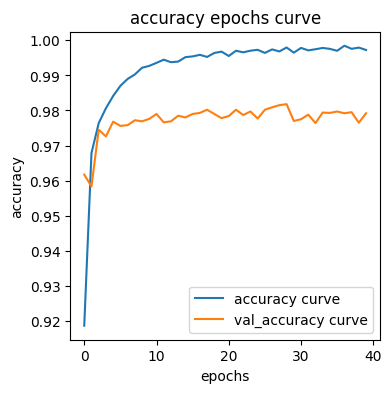

In [5]:
plt.figure(figsize=(4,4))
plt.plot(history.history["accuracy"],label = "accuracy curve")
plt.plot(history.history["val_accuracy"],label = "val_accuracy curve")
plt.title("accuracy epochs curve")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

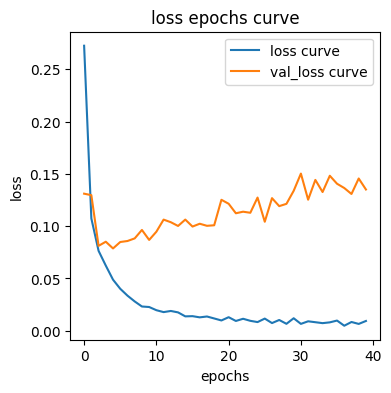

In [6]:
plt.figure(figsize=(4,4))
plt.plot(history.history["loss"],label = "loss curve")
plt.plot(history.history["val_loss"],label = "val_loss curve")
plt.title("loss epochs curve")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [7]:
index = 2
new_image = x_test[index].reshape(1,784)
prediction = model.predict(new_image)
predicted_digit = np.argmax(prediction)
predicted_digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


np.int64(1)

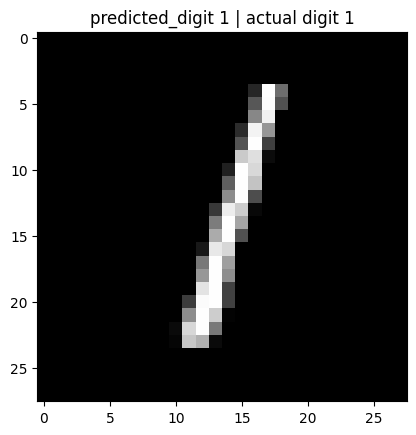

In [8]:
plt.imshow(x_test[index].reshape(28,28),cmap="grey")
plt.axis("on")
plt.title("predicted_digit "+str(predicted_digit) + " | actual digit "+str(y_test[index]))
plt.show()

regularization
it is used to reduce the overfitting by implementing the penalty

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization()
])